# Phase 1 Create Data Audit Notebook

In [1]:
import pandas as pd
import numpy as np

df=pd.read_csv("../AHSRAE.csv")

df.head()

,Unnamed: 0,building_id,meter,timestamp,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,primary_use,square_feet,year_built,floor_count
0,16777087,1020,0,2016-11-02 00:00:00,86.6301,10,8.9,4.0,3.3,0.0,1016.5,350.0,3.6,Entertainment/public assembly,22101,NaN,2.0
1,15143945,987,2,2016-10-04 00:00:00,228.7500,9,27.8,0.0,15.6,0.0,1010.0,110.0,2.6,Education,166395,NaN,NaN
2,903842,113,0,2016-01-17 19:00:00,335.6250,1,3.6,NaN,1.5,NaN,1023.0,120.0,4.6,Education,100481,1958.0,9.0
3,10190603,293,0,2016-07-07 05:00:00,777.2200,3,27.2,0.0,24.4,0.0,1011.0,170.0,3.1,Office,408000,2010.0,NaN
4,9600591,1176,2,2016-06-26 15:00:00,238.2810,13,25.0,2.0,10.0,0.0,1014.5,250.0,5.1,Education,142672,NaN,NaN


## Dataset Shape

In [2]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 409
Columns: 17


## Data Types

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          409 non-null    int64  
 1   building_id         409 non-null    int64  
 2   meter               409 non-null    int64  
 3   timestamp           409 non-null    str    
 4   meter_reading       409 non-null    float64
 5   site_id             409 non-null    int64  
 6   air_temperature     408 non-null    float64
 7   cloud_coverage      225 non-null    float64
 8   dew_temperature     408 non-null    float64
 9   precip_depth_1_hr   327 non-null    float64
 10  sea_level_pressure  385 non-null    float64
 11  wind_direction      382 non-null    float64
 12  wind_speed          407 non-null    float64
 13  primary_use         409 non-null    str    
 14  square_feet         409 non-null    int64  
 15  year_built          164 non-null    float64
 16  floor_count        

## Missing Values Assesment

In [4]:
df.isnull().sum()

Unnamed: 0              0
building_id             0
meter                   0
timestamp               0
meter_reading           0
site_id                 0
air_temperature         1
cloud_coverage        184
dew_temperature         1
precip_depth_1_hr      82
sea_level_pressure     24
wind_direction         27
wind_speed              2
primary_use             0
square_feet             0
year_built            245
floor_count           330
dtype: int64

## Percentage Missing

In [5]:
missing_pct = (
    df.isnull()
      .sum()
      / len(df)
      * 100
)

missing_pct.sort_values(ascending=False)

floor_count           80.684597
year_built            59.902200
cloud_coverage        44.987775
precip_depth_1_hr     20.048900
wind_direction         6.601467
sea_level_pressure     5.867971
wind_speed             0.488998
dew_temperature        0.244499
air_temperature        0.244499
building_id            0.000000
site_id                0.000000
meter_reading          0.000000
timestamp              0.000000
primary_use            0.000000
square_feet            0.000000
meter                  0.000000
Unnamed: 0             0.000000
dtype: float64

## Phase 2 Initial Data Quality Report

### Timestamp Conversion

In [ ]:
df["timestamp"] = pd.to_datetime(
    df["timestamp"]
)


In [7]:
df["timestamp"].dtype

dtype('<M8[us]')

### Duplicate Check

In [8]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


### Description Statistics

In [9]:
df.describe()

,Unnamed: 0,building_id,meter,timestamp,meter_reading,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,square_feet,year_built,floor_count
count,4.090000e+02,409.000000,409.000000,409,409.000000,409.000000,408.000000,225.000000,408.000000,327.000000,385.000000,382.000000,407.000000,409.000000,164.00000,79.000000
mean,9.847234e+06,810.437653,0.667482,2016-06-30 03:34:02.053789,360.381163,8.158924,15.653676,1.848889,7.103186,1.051988,1016.192208,164.581152,3.285258,106600.843521,1966.79878,3.455696
min,1.357000e+03,7.000000,0.000000,2016-01-01 01:00:00,0.000000,0.000000,-20.000000,0.000000,-24.400000,-1.000000,998.000000,0.000000,0.000000,356.000000,1900.00000,1.000000
25%,4.385210e+06,379.000000,0.000000,2016-03-25 01:00:00,18.490000,3.000000,7.800000,0.000000,-1.100000,0.000000,1012.000000,70.000000,2.100000,31614.000000,1950.00000,1.000000
50%,1.009423e+07,920.000000,0.000000,2016-07-05 11:00:00,84.000000,9.000000,16.700000,0.000000,7.200000,0.000000,1016.500000,165.000000,3.100000,69876.000000,1967.00000,2.000000
75%,1.500372e+07,1185.000000,1.000000,2016-10-01 13:00:00,285.111000,13.000000,24.400000,4.000000,15.600000,0.000000,1020.500000,267.500000,4.100000,133100.000000,1991.00000,5.000000
max,2.005000e+07,1442.000000,3.000000,2016-12-30 15:00:00,7978.500000,15.000000,43.300000,9.000000,25.000000,191.000000,1038.000000,360.000000,12.400000,764237.000000,2016.00000,13.000000
std,5.979208e+06,426.820314,0.921925,NaN,848.988751,5.048944,11.136192,2.462996,10.499251,11.046210,6.625742,112.400238,2.194761,115012.956370,30.53494,2.885852


### First KPI 

In [10]:
total_energy = df["meter_reading"].sum()

print(total_energy)

147395.8958


# Data Visualitzation

Matplotlib is building the font cache; this may take a moment.


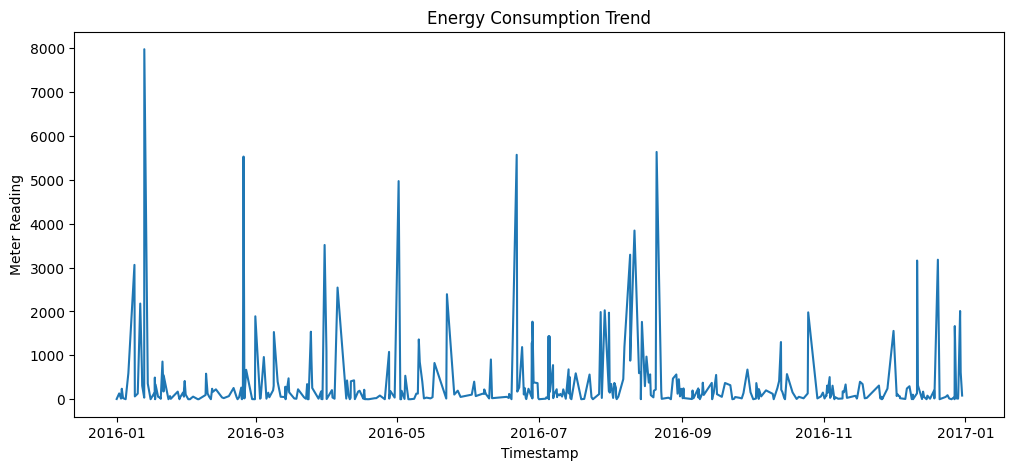

In [11]:
import matplotlib.pyplot as plt

daily_usage = (
    df.groupby("timestamp")
      ["meter_reading"]
      .sum()
)

plt.figure(figsize=(12,5))
plt.plot(daily_usage)
plt.title("Energy Consumption Trend")
plt.xlabel("Timestamp")
plt.ylabel("Meter Reading")
plt.show()

In [15]:
df.to_csv("../reports/audited_data.csv", index=False)

In [ ]:
npx docsify-cli serve "Energy Analytics & Sustainability Reporting Platform/docs" -p 3000